# Projet CO2 - Exploration des données

## Contexte

L’objectif de ce projet est d’analyser les émissions de CO2 des véhicules commercialisés en France afin d’identifier les facteurs influençant la pollution.

## Objectif

- Comprendre la structure du jeu de données
- Identifier les variables influençant les émissions de CO2
- Mettre en évidence des tendances à l’aide de visualisations
- Préparer les données pour une future modélisation

In [1]:
print("Projet CO2")

Projet CO2


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des données 2014

Nous importons le jeu de données contenant les caractéristiques techniques des véhicules commercialisés en France en 2014.

Le fichier est encodé en `latin1` et utilise le séparateur `;`. Ces paramètres doivent être précisés lors de la lecture du fichier avec pandas.

In [3]:
df_2014 = pd.read_csv("../data/co2_2014.csv", encoding="latin1", sep=";")
df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,...,1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,...,1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN


## Aperçu des données 2014

Les premières lignes du jeu de données permettent d’observer les différentes variables disponibles, comme la marque du véhicule, le type de carburant, la puissance moteur, la masse ou encore les émissions de CO₂.

In [5]:
# Nombre de lignes et colonnes
df_2014.shape

(55044, 30)

Le jeu de données contient 55 044 lignes et 30 colonnes.

In [6]:
# Informations générales
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

La majorité des variables sont de type object. Certaines variables quantitatives semblent mal typées et devront être converties.

In [7]:
# Statistiques descriptives
df_2014.describe(include='all')

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
count,55044,55044,55044,55044,55044,55044,55044,55044,55044.000000,55044,...,55044.000000,55044.000000,54983,3247,55044,55044,0.0,0.0,0.0,0.0
unique,46,483,434,3837,54982,35430,13,2,NaN,232,...,NaN,NaN,35,5,11,7,NaN,NaN,NaN,NaN
top,MERCEDES,VIANO,VIANO,VIANO 2.2 CDI,M10ALFVP000K441,F142ABE,GO,non,NaN,120,...,NaN,NaN,"""715/2007*692/2008EURO5",mars-14,MINIBUS,MOY-INFER,NaN,NaN,NaN,NaN
freq,36220,14031,14031,5874,2,4,49311,54655,NaN,19968,...,NaN,NaN,23979,2810,46107,33438,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.551504,NaN,...,2102.104553,2341.021801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.126021,NaN,...,294.731715,424.067895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,825.000000,825.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,...,1982.000000,2075.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,...,2076.000000,2355.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,...,2246.000000,2709.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Les statistiques descriptives mettent en évidence une forte diversité des véhicules et certaines colonnes à forte cardinalité.

Certaines variables contiennent un nombre important de valeurs manquantes, notamment hc, hcnox et les colonnes Unnamed.

In [9]:
df_2014.describe()
df_2014.isnull().sum()

lib_mrq                  0
lib_mod_doss             0
lib_mod                  0
dscom                    0
cnit                     0
tvv                      0
cod_cbr                  0
hybride                  0
puiss_admin_98           0
puiss_max                0
typ_boite_nb_rapp        0
conso_urb               43
conso_exurb             43
conso_mixte             34
co2                     34
co_typ_1               158
hc                   45271
nox                    158
hcnox                 9888
ptcl                  2678
masse_ordma_min          0
masse_ordma_max          0
champ_v9                61
date_maj             51797
Carrosserie              0
gamme                    0
Unnamed: 26          55044
Unnamed: 27          55044
Unnamed: 28          55044
Unnamed: 29          55044
dtype: int64

## Structure des données
Le jeu de données 2014 contient 55 044 observations et 30 variables décrivant les caractéristiques techniques et environnementales des véhicules commercialisés en France.

Les variables présentes dans le dataset concernent notamment :

la marque et le modèle des véhicules,
le type de carburant,
la puissance moteur,
la consommation de carburant,
la masse des véhicules,
les émissions polluantes.

On distingue principalement deux types de variables :

des variables catégorielles (object) :
marque,
carburant,
carrosserie,
type de boîte de vitesse,
gamme du véhicule.

des variables numériques (int64 et float64) :
émissions de CO₂,
puissance administrative,
masse du véhicule,
consommation.

L’analyse des types de données met également en évidence plusieurs variables quantitatives stockées au format object. Une conversion sera nécessaire lors des étapes de preprocessing afin de faciliter les analyses statistiques et la modélisation.

Certaines variables présentent des valeurs manquantes, notamment :

hc,
hcnox,
ptcl,
ainsi que les colonnes Unnamed, totalement vides.

Ces colonnes inutiles devront être supprimées afin d’améliorer la qualité du dataset.

Les variables les plus pertinentes pour l’analyse des émissions de CO₂ semblent être :

co2,
conso_mixte,
puiss_max,
masse_ordma_min,
cod_cbr,
hybride.

L’analyse statistique descriptive met en évidence une forte diversité des véhicules présents dans le dataset, avec des écarts importants de puissance, de masse et de consommation.

## Nettoyage minimal AVANT visualisations

## Supprimer les colonnes inutiles

In [10]:
df_2014 = df_2014.drop(columns=[
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29'
])

## Convertir les colonnes numériques mal typées

In [11]:
colonnes_numeriques = [
    'puiss_max',
    'conso_urb',
    'conso_exurb',
    'conso_mixte',
    'hc',
    'nox',
    'hcnox',
    'ptcl'
]

for col in colonnes_numeriques:
    df_2014[col] = pd.to_numeric(df_2014[col], errors='coerce')

## Vérifier les nouveaux types

In [12]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          54851 non-null  float64
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          6124 non-null   float64
 12  conso_exurb        4545 non-null   float64
 13  conso_mixte        6496 non-null   float64
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 580 non-null  

## Observations après nettoyage

La suppression des colonnes inutiles a permis de réduire le dataset à 26 variables exploitables.

La conversion des variables quantitatives stockées au format object vers un format numérique (float64) a également mis en évidence un grand nombre de valeurs invalides ou manquantes dans certaines colonnes environnementales comme :

hc,
nox,
hcnox,
ptcl.

Ces valeurs ont été automatiquement converties en NaN grâce au paramètre errors='coerce'.

Certaines variables apparaissent donc peu exploitables pour la suite de l’analyse en raison du nombre très important de données manquantes.

Le nettoyage réalisé permet désormais d’obtenir un dataset plus cohérent et adapté aux futures visualisations et analyses statistiques.

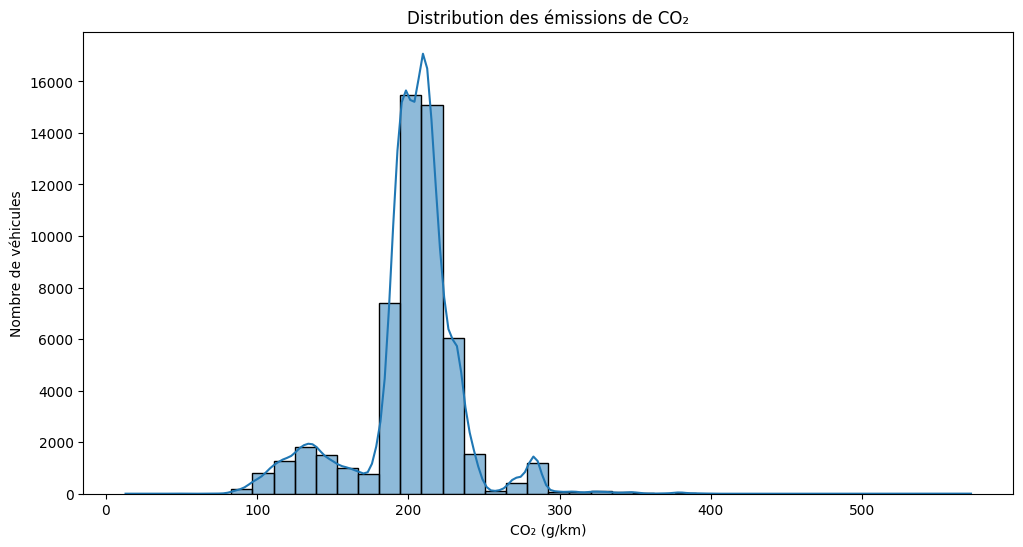

In [16]:
plt.figure(figsize=(12,6))

sns.histplot(df_2014['co2'], bins=40, kde=True)

plt.title("Distribution des émissions de CO₂")
plt.xlabel("CO₂ (g/km)")
plt.ylabel("Nombre de véhicules")

plt.show()

## Analyse de la distribution des émissions de CO₂

La distribution des émissions de CO₂ des véhicules commercialisés en France en 2014 montre une forte concentration des véhicules entre 180 et 230 g/km.

La distribution présente une asymétrie vers la droite, traduisant la présence de véhicules fortement émetteurs. Quelques valeurs extrêmes dépassent 300 g/km.

On observe également plusieurs pics dans la distribution, ce qui peut s’expliquer par :

différents types de motorisations,
différentes catégories de véhicules,
ou encore des différences de carburants.

La majorité des véhicules reste néanmoins regroupée autour des valeurs moyennes d’émission.

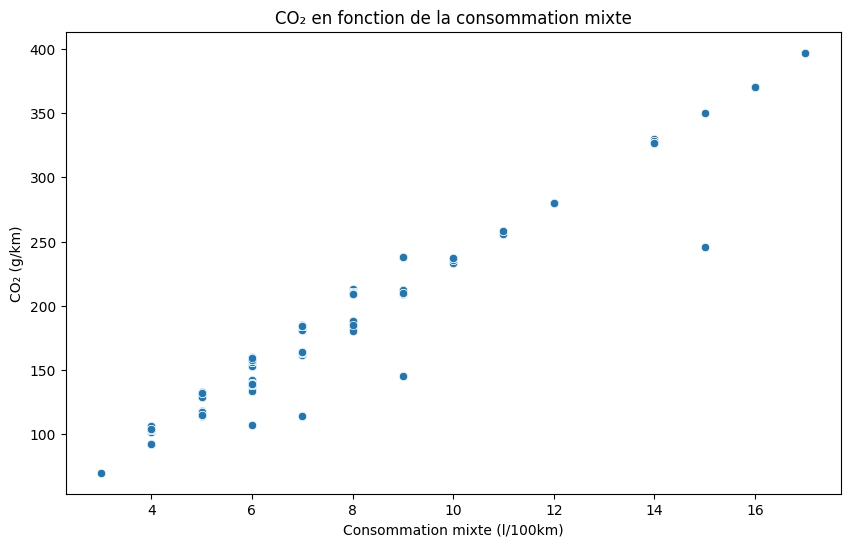

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='conso_mixte',
    y='co2',
    data=df_2014
)

plt.title("CO₂ en fonction de la consommation mixte")
plt.xlabel("Consommation mixte (l/100km)")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ en fonction de la consommation mixte

Le graphique met en évidence une relation positive très marquée entre la consommation mixte des véhicules et leurs émissions de CO₂.

Plus la consommation de carburant augmente, plus les émissions de CO₂ augmentent également. Les points sont fortement alignés, ce qui traduit une relation quasi linéaire entre les deux variables.

Les véhicules les plus consommateurs, au-delà de 12 l/100 km, présentent logiquement les niveaux d’émissions les plus élevés.

Cette observation confirme que la consommation mixte constitue l’un des principaux facteurs explicatifs des émissions de CO₂ dans le dataset.

## Validation statistique

In [18]:
df_2014[['conso_mixte', 'co2']].corr()

,conso_mixte,co2
conso_mixte,1.000000,0.973868
co2,0.973868,1.000000


La corrélation calculée entre la consommation mixte et les émissions de CO₂ est très élevée (0,97), ce qui confirme quantitativement la forte relation observée sur le graphique.

Cette corrélation proche de 1 indique que les véhicules consommant davantage de carburant sont également ceux qui émettent le plus de CO₂.

La consommation mixte apparaît ainsi comme l’une des variables les plus explicatives des émissions polluantes dans ce jeu de données.

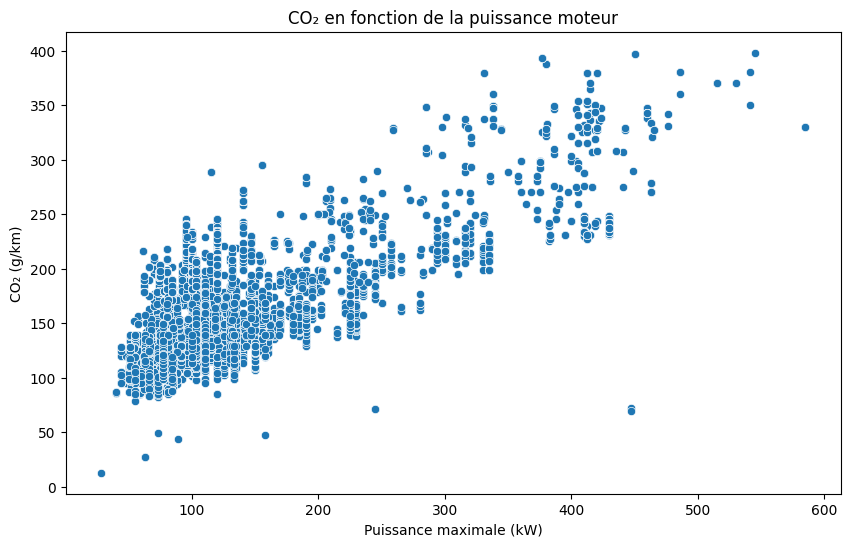

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='puiss_max',
    y='co2',
    data=df_2014
)

plt.title("CO₂ en fonction de la puissance moteur")
plt.xlabel("Puissance maximale (kW)")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ en fonction de la puissance moteur

Le graphique met en évidence une relation positive entre la puissance moteur et les émissions de CO₂.

Globalement, les véhicules les plus puissants tendent à produire davantage d’émissions polluantes. Cette tendance apparaît clairement avec l’augmentation progressive des valeurs de CO₂ lorsque la puissance maximale augmente.

Cependant, la dispersion des points reste plus importante que pour la consommation mixte, ce qui indique que la puissance moteur n’explique pas à elle seule les émissions de CO₂.

D’autres facteurs, comme :

la masse du véhicule,
le type de carburant,
ou encore la consommation,

semblent également jouer un rôle important dans les niveaux d’émissions observés.

## Validation statistique

In [20]:
df_2014[['puiss_max', 'co2']].corr()

,puiss_max,co2
puiss_max,1.000000,0.331356
co2,0.331356,1.000000


La corrélation calculée entre la puissance moteur et les émissions de CO₂ est positive mais modérée (0,33).

Ce résultat confirme la tendance observée graphiquement : les véhicules les plus puissants ont globalement tendance à émettre davantage de CO₂.

Cependant, cette corrélation reste nettement plus faible que celle observée avec la consommation mixte, ce qui montre que la puissance moteur n’est pas le facteur principal expliquant les émissions polluantes.

Les émissions de CO₂ dépendent donc également d’autres caractéristiques du véhicule, comme la consommation, la masse ou le type de carburant.

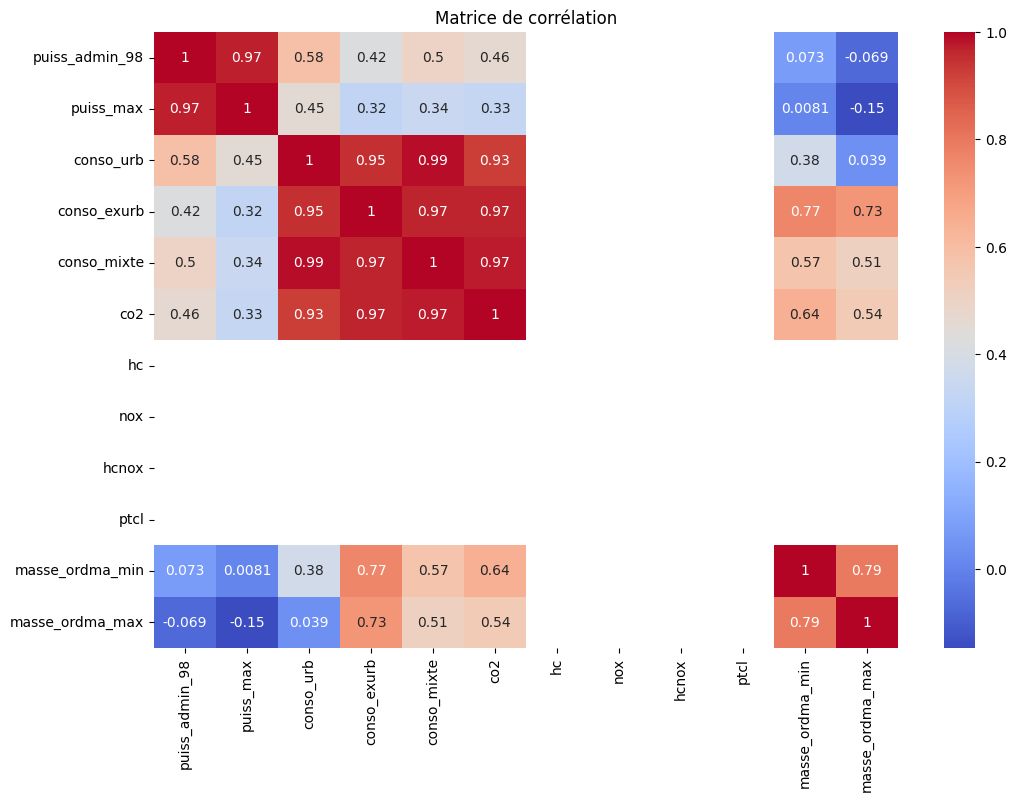

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_2014.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()

## Analyse de la matrice de corrélation

La matrice de corrélation permet d’identifier les relations linéaires entre les différentes variables quantitatives du jeu de données.

Plusieurs corrélations fortes apparaissent :

- La consommation mixte et les émissions de CO₂ présentent une très forte corrélation positive (0,97).
- Les consommations urbaine, extra-urbaine et mixte sont également très fortement corrélées entre elles.
- La puissance maximale présente une corrélation positive plus modérée avec le CO₂ (0,33).

La masse des véhicules semble également influencer les émissions de CO₂, avec une corrélation positive notable entre la masse et les émissions polluantes.

Certaines zones de la matrice apparaissent vides en raison d’un nombre important de valeurs manquantes dans certaines variables liées aux polluants (`hc`, `nox`, `hcnox`, `ptcl`). Ces données incomplètes ne permettent pas de calculer des corrélations fiables pour ces variables.

Cette analyse confirme que la consommation constitue le facteur le plus directement lié aux émissions de CO₂ dans ce jeu de données.

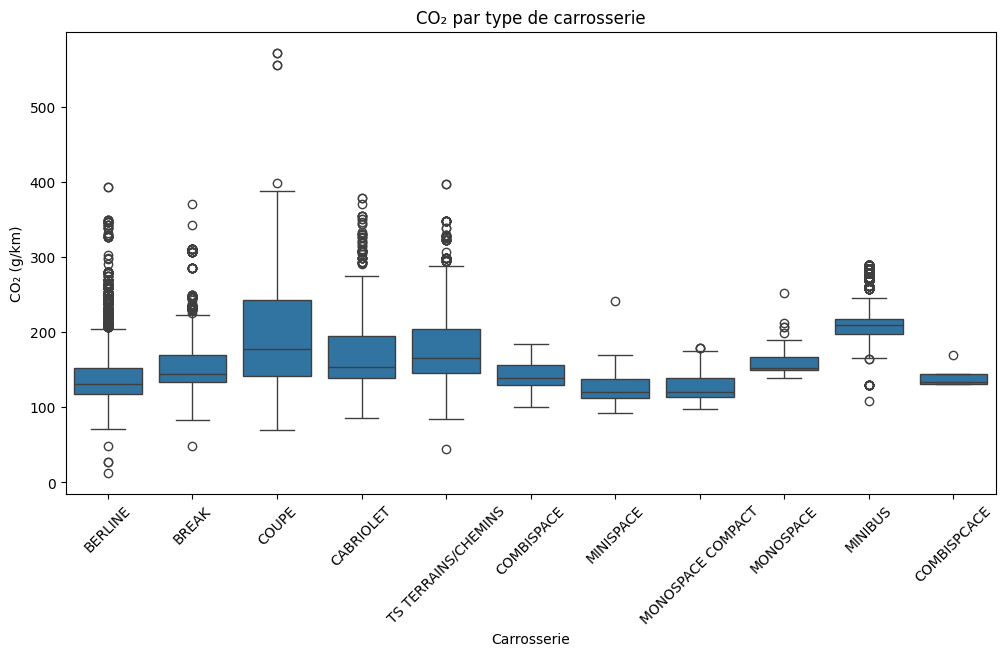

In [22]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Carrosserie',
    y='co2',
    data=df_2014
)

plt.xticks(rotation=45)

plt.title("CO₂ par type de carrosserie")
plt.xlabel("Carrosserie")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ par type de carrosserie

Le graphique met en évidence des différences d’émissions de CO₂ selon les types de carrosserie des véhicules.

Les véhicules de type :
- `COUPE`,
- `MINIBUS`,
- et certains `TS TERRAINS/CHEMINS`

présentent globalement les niveaux d’émissions les plus élevés ainsi qu’une forte dispersion des valeurs.

À l’inverse, les véhicules de type :
- `MINISPACE`,
- `MONOSPACE COMPACT`,
- ou `COMBISPACE`

affichent des émissions plus faibles et plus homogènes.

La présence de nombreux points atypiques (outliers) montre également que certains modèles particuliers émettent des quantités de CO₂ nettement supérieures à la moyenne de leur catégorie.

Cette analyse suggère que le type de carrosserie influence les émissions polluantes, probablement en lien avec la taille, la masse et la puissance des véhicules.

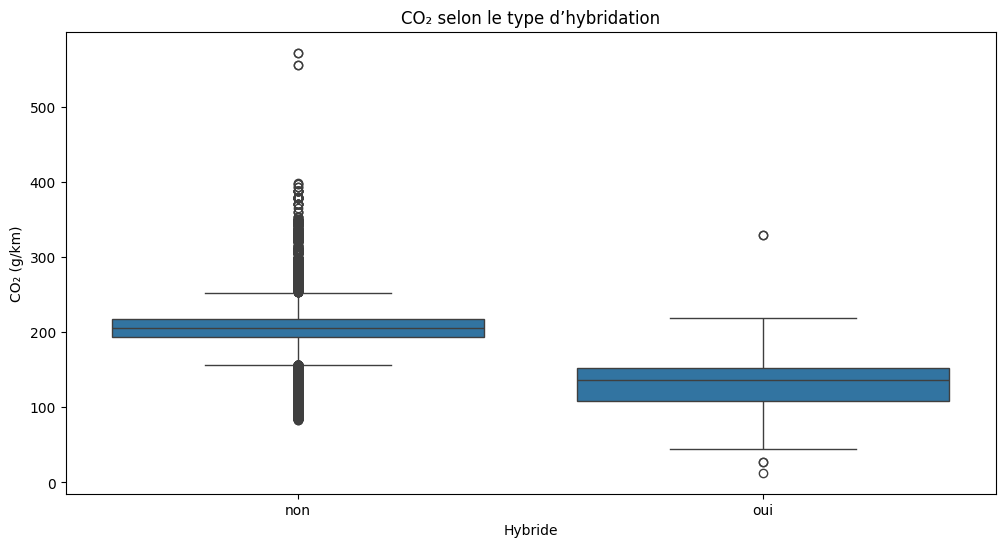

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='hybride',
    y='co2',
    data=df_2014
)

plt.title("CO₂ selon le type d’hybridation")
plt.xlabel("Hybride")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ selon le type d’hybridation

Le graphique compare les émissions de CO₂ entre les véhicules hybrides et non hybrides.

Les véhicules hybrides (`oui`) présentent globalement des émissions de CO₂ plus faibles que les véhicules non hybrides (`non`).

La médiane des émissions est nettement inférieure pour les véhicules hybrides, ce qui suggère un impact positif de l’hybridation sur la réduction des émissions polluantes.

Les véhicules non hybrides affichent également une plus grande dispersion des valeurs ainsi qu’un nombre important de valeurs extrêmes, avec certains modèles dépassant largement les 300 g/km de CO₂.

Cette analyse met en évidence l’intérêt des technologies hybrides dans la diminution des émissions de CO₂ des véhicules commercialisés en 2014.

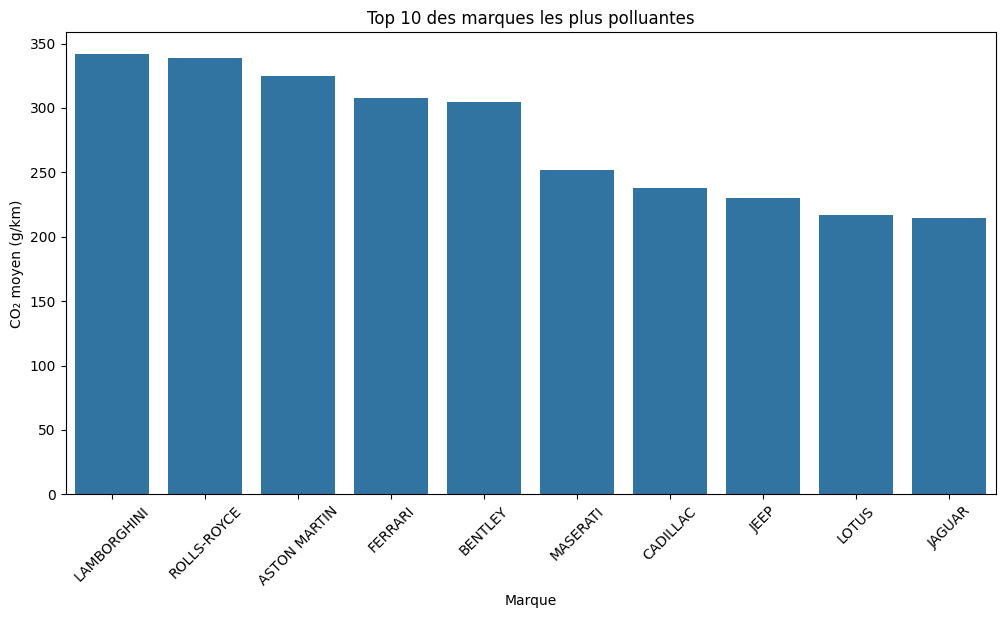

In [25]:
top_marques = (
    df_2014.groupby('lib_mrq')['co2']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_marques.index,
    y=top_marques.values
)

plt.xticks(rotation=45)

plt.title("Top 10 des marques les plus polluantes")
plt.xlabel("Marque")
plt.ylabel("CO₂ moyen (g/km)")

plt.show()

## Analyse des marques les plus polluantes

Le graphique présente les dix marques affichant les émissions moyennes de CO₂ les plus élevées dans le jeu de données de 2014.

Les marques :
- `LAMBORGHINI`,
- `ROLLS-ROYCE`,
- `ASTON MARTIN`,
- `FERRARI`
- et `BENTLEY`

occupent les premières positions avec des émissions moyennes particulièrement importantes.

Ces résultats s’expliquent principalement par le positionnement de ces marques sur des véhicules :
- sportifs,
- haut de gamme,
- puissants,
- et souvent plus lourds.

À l’inverse, certaines marques plus généralistes ou orientées vers des véhicules compacts apparaissent moins présentes dans ce classement.

Cette analyse confirme le lien entre performances automobiles, puissance moteur et niveau d’émissions de CO₂.

## Chargement des données 2014

In [10]:
df_2014 = pd.read_csv("data/mars-2014-complete.csv", encoding="latin1", sep=";")
df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,...,1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,...,1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
